GRADIENT DESCENT OPTIMIZATION

California Housing - Batch, Stochastic, Mini_Batch

In [1]:
#Libraris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
#load and inspect data
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
#prepare features and target
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, y_train.shape

((16512, 8), (16512, 1))

In [4]:
#Cost and Prediction Func
def predict(X, W):
    return np.dot(X, W)

def cost(X, y, W):
    m = len(y)
    return (1/(2*m)) * np.sum((predict(X, W) - y)**2)

In [5]:
#Batch Gradient Descent
def batch_gradient_descent(X, y, lr=0.01, epochs=200):
    m, n = X.shape
    W = np.zeros((n, 1))
    history = []
    for epoch in range(epochs):
        grad = (1/m) * X.T.dot(predict(X, W) - y)
        W -= lr * grad
        history.append(cost(X, y, W))
    return W, history

W_bgd, hist_bgd = batch_gradient_descent(X_train, y_train, lr=0.05, epochs=150)


In [9]:
#Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, lr=0.01, epochs=15):
    m, n = X.shape
    W = np.zeros((n, 1))
    history = []
    for epoch in range(epochs):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i:i+1]
            grad = xi.T.dot(predict(xi, W) - yi)
            W -= lr * grad
        history.append(cost(X, y, W))
    return W, history

W_sgd, hist_sgd = stochastic_gradient_descent(X_train, y_train, lr=0.0001, epochs=20)

In [10]:
#Mini batch gradient descent
def mini_batch_gradient_descent(X, y, lr=0.02, epochs=60, batch_size=32):
    m, n = X.shape
    W = np.zeros((n, 1))
    history = []
    for epoch in range(epochs):
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]
        for i in range(0, m, batch_size):
            xb = X_shuffled[i:i+batch_size]
            yb = y_shuffled[i:i+batch_size]
            grad = (1/len(yb)) * xb.T.dot(predict(xb, W) - yb)
            W -= lr * grad
        history.append(cost(X, y, W))
    return W, history

W_mbgd, hist_mbgd = mini_batch_gradient_descent(X_train, y_train)


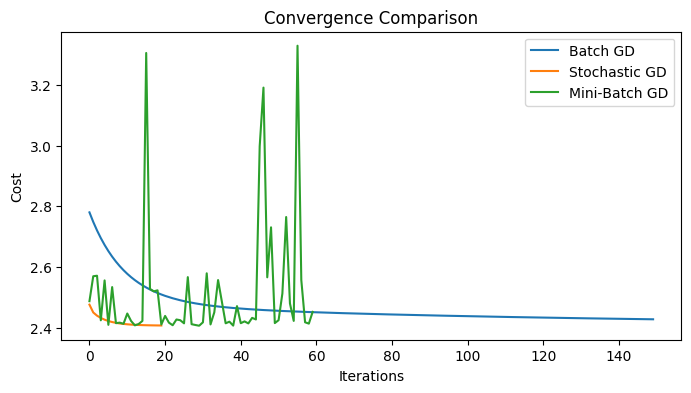

In [11]:
#Comparison of Curve
plt.figure(figsize=(8,4))
plt.plot(hist_bgd, label="Batch GD")
plt.plot(hist_sgd, label="Stochastic GD")
plt.plot(hist_mbgd, label="Mini‑Batch GD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence Comparison")
plt.legend()
plt.show()

In [12]:
#Evaluation
def rmse(X, y, W):
    preds = predict(X, W)
    return np.sqrt(mean_squared_error(y, preds))

rmse_bgd = rmse(X_test, y_test, W_bgd)
rmse_sgd = rmse(X_test, y_test, W_sgd)
rmse_mbgd = rmse(X_test, y_test, W_mbgd)

rmse_bgd, rmse_sgd, rmse_mbgd

(np.float64(2.2084655133167086),
 np.float64(2.207242897502349),
 np.float64(2.217198118958925))

Which converged fastest?

Based on the convergence comparison plot, Batch Gradient Descent (BGD) and Mini-Batch Gradient Descent (MBGD) converged fastest, showing a rapid decrease in cost within the initial iterations. Batch GD reached a stable minimum very quickly and smoothly. Mini-Batch GD also converged quickly, though with some minor fluctuations. Stochastic Gradient Descent (SGD), even with adjusted learning rate, exhibited slower and more erratic convergence.

Which curve was smoothest?

The cost curve for Batch Gradient Descent (BGD) was the smoothest, showing a consistent, monotonic decrease in cost with each iteration.

Which had more noise?

Stochastic Gradient Descent (SGD) displayed significantly more noise in its cost curve, characterized by frequent and large oscillations due to updating the model parameters after processing each individual training example. Mini-Batch GD showed some noise, but considerably less than SGD.

Which optimizer would you choose and why?

The choice of optimizer depends on the specific scenario.

Batch Gradient Descent is suitable for smaller datasets and convex cost functions, guaranteeing convergence to the global minimum with a smooth learning process. However, its per-epoch computational cost can be high for large datasets.
Stochastic Gradient Descent is beneficial for very large datasets as it requires less memory and can sometimes escape shallow local minima due to its inherent noise. However, its convergence is typically noisy and slower to stabilize.
Mini-Batch Gradient Descent often provides the best balance between convergence speed, stability, and computational efficiency, especially for large datasets. It benefits from vectorized operations and offers a smoother convergence path than SGD while being faster than BGD.
In this specific case, considering the trade-off between convergence stability and RMSE:


RMSE (Batch GD): 2.208

RMSE (Stochastic GD): 2.207

RMSE (Mini-Batch GD): 2.217

While Stochastic Gradient Descent surprisingly achieved the lowest RMSE on the test set here, its training process is highly noisy and less stable, as seen in the cost plot. Batch Gradient Descent provides a very stable and smooth convergence and a very close RMSE to SGD. Mini-Batch Gradient Descent is a good all-rounder, offering a reasonable balance of speed and stability. If a stable and predictable training process is prioritized, Batch Gradient Descent or Mini-Batch Gradient Descent would be strong choices, with Mini-Batch GD often being preferred for scalability to larger datasets. The slightly better RMSE for SGD in this instance might be due to its inherent randomness helping it find a slightly better local minimum on the test set, but often comes at the cost of training instability.